In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
df=pd.read_csv("/content/df_file (1).csv")
df.head()

,Text,Label
0,Budget to set scene for election\n \n Gordon B...,0
1,Army chiefs in regiments decision\n \n Militar...,0
2,Howard denies split over ID cards\n \n Michael...,0
3,Observers to monitor UK election\n \n Minister...,0
4,Kilroy names election seat target\n \n Ex-chat...,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    2225 non-null   object
 1   Label   2225 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 34.9+ KB


In [4]:
df.shape

(2225, 2)

In [5]:
df.isnull().sum()

,0
Text,0
Label,0


EDA- Exploratiory Data Analysis


In [6]:
temp = df
temp['Label']= temp['Label'].map({0:'Politics',1:'Sport',2:'Technology',3:'Entertainment',4:'Business'})
temp

,Text,Label
0,Budget to set scene for election\n \n Gordon B...,Politics
1,Army chiefs in regiments decision\n \n Militar...,Politics
2,Howard denies split over ID cards\n \n Michael...,Politics
3,Observers to monitor UK election\n \n Minister...,Politics
4,Kilroy names election seat target\n \n Ex-chat...,Politics
...,...,...
2220,India opens skies to competition\n \n India wi...,Business
2221,Yukos bankruptcy 'not US matter'\n \n Russian ...,Business
2222,Survey confirms property slowdown\n \n Governm...,Business
2223,High fuel prices hit BA's profits\n \n British...,Business


In [7]:
label_counts = temp["Label"].value_counts()
label_counts

,count
Label,
Sport,511
Business,510
Politics,417
Technology,401
Entertainment,386


In [32]:
from __future__ import annotations
import plotly.graph_objects as go

#count labels
label_counts= temp["Label"].value_counts()

#create pie chart
fig = go.Figure(go.Pie(labels=label_counts.index,
                       values=label_counts,
                       hole=0.5,
                       marker=dict(colors=['#FF5733','#33FF57','#3357FF'])))
fig.update_layout(title="Label Distribution",
                  width=1200,
                  template="plotly_white",
                  annotations=[dict(text="Label",x=0.5,y=0.5,showarrow=False,font_size=12,font_color="white")])
#show chart
fig.show()

In [9]:
temp

,Text,Label
0,Budget to set scene for election\n \n Gordon B...,Politics
1,Army chiefs in regiments decision\n \n Militar...,Politics
2,Howard denies split over ID cards\n \n Michael...,Politics
3,Observers to monitor UK election\n \n Minister...,Politics
4,Kilroy names election seat target\n \n Ex-chat...,Politics
...,...,...
2220,India opens skies to competition\n \n India wi...,Business
2221,Yukos bankruptcy 'not US matter'\n \n Russian ...,Business
2222,Survey confirms property slowdown\n \n Governm...,Business
2223,High fuel prices hit BA's profits\n \n British...,Business


In [33]:
fig = px.histogram(data_frame=temp,x='Label',marginal='violin')
fig.update_layout(width=1000, title="Distribution of Labels", template='plotly_dark')
fig.show()

Text Cleaning and Preprocessing

In [12]:
import re # Regular expressions

import nltk # Natural language processing

#nltk.download('vader_lexicon') # Download VADER lexicon

from nltk.corpus import stopwords # Stopwords

nltk.download('stopwords') # Download stopwords corpus

#Get the stopwords for the language.

stpwrds= stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [13]:
# General transformation in the text
def transformation(df, mc,):

    df[mc] = df[mc].replace("\n"," ").replace("\t"," ")
    df[mc] = df[mc].str.lower()
    df[mc] = df[mc].apply(lambda x: re.sub('@[^\s]+', '', x))  #Removes Twitter-style mentions (e.g., @username) from the text.
    df[mc] = df[mc].apply(lambda x: re.sub(r'\B#\S+', '', x))   #Removes hashtags (e.g., #hashtag) from the text.
    df[mc] = df[mc].apply(lambda x: re.sub(r"http\S+", "", x))  #Removes URLs from the text.
    df[mc] = df[mc].apply(lambda x: ' '.join(re.findall(r'\w+', x)))  #Keeps only alphanumeric characters (words) and removes everything else.
    df[mc] = df[mc].apply(lambda x: re.sub(r'\s+[b-zA-Z]\s+', ' ', x)) #Removes single characters (letters) that are surrounded by spaces, which are often
                                                                          # insignificant in text analysis.
    df[mc] = df[mc].apply(lambda x: re.sub(r'\s+', ' ', x, flags=re.I))  #Replaces multiple whitespace characters (spaces, tabs) with a single space.

    df[mc] = df[mc].apply(lambda x: ' '.join([word for word in x.split() if word not in stpwrds]))  #Removes stop words
                                        #(common words that may not add significant meaning) from the text. stpwrds is assumed to be a predefined list of stop words.

    df['words'] = df[mc].apply(lambda x: re.findall(r'\w+', x)) #Creates a new column words that contains lists of words extracted from the text.
    df['words_count'] = df.words.apply(len)  #Calculates the number of words in each text and stores it in a new column words_count.
    df['length'] = df[mc].apply(len)  #Computes the length of the text (number of characters) and stores it in a new column length.

    return df


In [14]:
data= transformation(df,'Text')
data.head()

,Text,Label,words,words_count,length
0,budget set scene election gordon brown seek pu...,Politics,"[budget, set, scene, election, gordon, brown, ...",330,2231
1,army chiefs regiments decision military chiefs...,Politics,"[army, chiefs, regiments, decision, military, ...",273,2078
2,howard denies split id cards michael howard de...,Politics,"[howard, denies, split, id, cards, michael, ho...",316,2178
3,observers monitor uk election ministers invite...,Politics,"[observers, monitor, uk, election, ministers, ...",302,2277
4,kilroy names election seat target ex chat show...,Politics,"[kilroy, names, election, seat, target, ex, ch...",275,1857


In [15]:
fig = px.histogram(data_frame=data,x='words_count',marginal='violin')
fig.update_layout(width=1000, title="Word Count", template='plotly_dark')
fig.show()

In [16]:
fig = px.histogram(data_frame=data,x='length',marginal='violin')
fig.update_layout(width=1000, title="Word Length", template='plotly_dark')
fig.show()

BOW (BAG OF WORDS)

In [17]:
#Import CounntVectorizer BOW
from sklearn.feature_extraction.text import CountVectorizer

#Create CountVectorizer object
vectorizer = CountVectorizer(ngram_range=(1,2))

#Generate Matrix of word vectors
count_vec = vectorizer.fit_transform(data['Text'])

#Print the shape of bo
count_vec.shape

(2225, 369424)

In [18]:
count_vec

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 825630 stored elements and shape (2225, 369424)>

In [19]:
#Create the CountVectorizer DataFrame: count_df

count_df = pd.DataFrame(count_vec.toarray(), columns=vectorizer.get_feature_names_out())
count_df.head()

,00,00 59,00 early,00 mark,00 per,00 qualifying,00 work,000,000 000,000 10,...,zurich reported,zutons,zutons 20,zvonareva,zvonareva lost,zvonareva russia,zvonareva struggled,zvonareva wimbledon,zvyagintsev,zvyagintsev return
0,0,0,0,0,0,0,0,5,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
"""# Calculate the difference in columns: difference
difference = count_df.columns.difference(data.columns)
print(difference)

# Check whether the DataFrames are equal
print(count_df.equals(data))
"""

'# Calculate the difference in columns: difference\ndifference = count_df.columns.difference(data.columns)\nprint(difference)\n\n# Check whether the DataFrames are equal\nprint(count_df.equals(data))\n'

Prediction using the Count Vectorizer

In [22]:
y = df['Label'].values

In [23]:
X = count_df

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,stratify=y,shuffle=True,test_size=0.3)

In [25]:
from sklearn.metrics import log_loss, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)
logloss = log_loss(y_test, y_pred_proba)
print("Log Loss value from Randomforest model = ",logloss)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy value from Randomforest model = ",accuracy)

Log Loss value from Randomforest model =  0.513538558190502
Accuracy value from Randomforest model =  0.9565868263473054


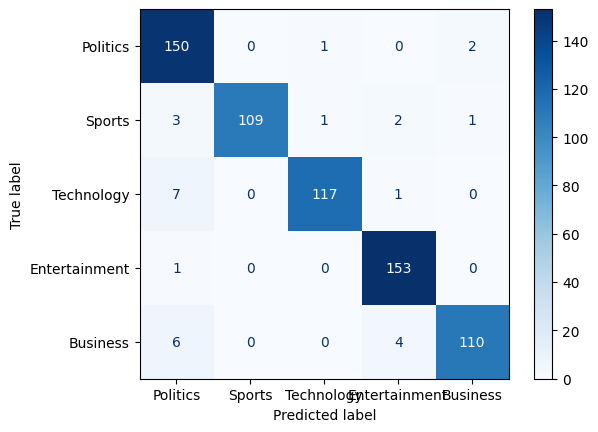

In [26]:
#Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test,display_labels=("Politics","Sports","Technology","Entertainment","Business"),cmap="Blues")
plt.show()

In [30]:
def prediction(text:str):
  #Assuming 'vectorizer' is a pretrained vectorizer
  word_vector = vectorizer.transform([text])

  #Assumin Random Forest
  prediction_model = rf_model.predict(word_vector.astype(np.float64))
  return prediction_model

In [31]:
#Example Usage

example_text = "Nothing beats the joy of sharing with friends while watching a baseball game on a sunny afternoon"
prediction_value = prediction(example_text)
print("Prediction: ",prediction_value)

Prediction:  ['Sport']
